In [559]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("task2.csv", encoding="cp1252-")
df

,Unnamed: 0,ID,Name,Age,Photo,Nationality,Flag,Overall,Potential,Club,...,Composure,Marking,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Release Clause
0,0,158023,L. Messi,31.0,https://cdn.sofifa.org/players/4/19/158023.png,Argentina,https://cdn.sofifa.org/flags/52.png,94.0,94,FC Barcelona,...,96.0,33.0,28.0,26.0,6.0,11.0,15.0,14.0,8.0,€226.5M
1,1,20801,Cristiano Ronaldo,33.0,https://cdn.sofifa.org/players/4/19/20801.png,Portugal,https://cdn.sofifa.org/flags/38.png,94.0,94,Juventus,...,95.0,28.0,31.0,23.0,7.0,11.0,15.0,14.0,11.0,€127.1M
2,2,190871,Neymar Jr,26.0,https://cdn.sofifa.org/players/4/19/190871.png,Brazil,https://cdn.sofifa.org/flags/54.png,92.0,93,Paris Saint-Germain,...,94.0,27.0,24.0,33.0,9.0,9.0,15.0,15.0,11.0,€228.1M
3,3,193080,De Gea,27.0,https://cdn.sofifa.org/players/4/19/193080.png,Spain,https://cdn.sofifa.org/flags/45.png,91.0,93,Manchester United,...,68.0,15.0,21.0,13.0,90.0,85.0,87.0,88.0,94.0,€138.6M
4,4,192985,K. De Bruyne,27.0,https://cdn.sofifa.org/players/4/19/192985.png,Belgium,https://cdn.sofifa.org/flags/7.png,91.0,92,Manchester City,...,88.0,68.0,58.0,51.0,15.0,13.0,5.0,10.0,13.0,€196.4M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18202,18202,238813,J. Lundstram,19.0,https://cdn.sofifa.org/players/4/19/238813.png,England,https://cdn.sofifa.org/flags/14.png,47.0,65,Crewe Alexandra,...,45.0,40.0,48.0,47.0,10.0,13.0,7.0,8.0,9.0,€143K
18203,18203,243165,N. Christoffersson,19.0,https://cdn.sofifa.org/players/4/19/243165.png,Sweden,https://cdn.sofifa.org/flags/46.png,47.0,63,Trelleborgs FF,...,42.0,22.0,15.0,19.0,10.0,9.0,9.0,5.0,12.0,€113K
18204,18204,241638,B. Worman,16.0,https://cdn.sofifa.org/players/4/19/241638.png,England,https://cdn.sofifa.org/flags/14.png,47.0,67,Cambridge United,...,41.0,32.0,13.0,11.0,6.0,5.0,10.0,6.0,13.0,€165K
18205,18205,246268,D. Walker-Rice,17.0,https://cdn.sofifa.org/players/4/19/246268.png,England,https://cdn.sofifa.org/flags/14.png,47.0,66,Tranmere Rovers,...,46.0,20.0,25.0,27.0,14.0,6.0,14.0,8.0,9.0,€143K


In [560]:
df.columns

Index(['Unnamed: 0', 'ID', 'Name', 'Age', 'Photo', 'Nationality', 'Flag',
       'Overall', 'Potential', 'Club', 'Club Logo', 'Value', 'Wage', 'Special',
       'Preferred Foot', 'International Reputation', 'Weak Foot',
       'Skill Moves', 'Work Rate', 'Body Type', 'Real Face', 'Position',
       'Jersey Number', 'Joined', 'Loaned From', 'Contract Valid Until',
       'Height', 'Weight', 'LS', 'ST', 'RS', 'LW', 'LF', 'CF', 'RF', 'RW',
       'LAM', 'CAM', 'RAM', 'LM', 'LCM', 'CM', 'RCM', 'RM', 'LWB', 'LDM',
       'CDM', 'RDM', 'RWB', 'LB', 'LCB', 'CB', 'RCB', 'RB', 'Crossing',
       'Finishing', 'HeadingAccuracy', 'ShortPassing', 'Volleys', 'Dribbling',
       'Curve', 'FKAccuracy', 'LongPassing', 'BallControl', 'Acceleration',
       'SprintSpeed', 'Agility', 'Reactions', 'Balance', 'ShotPower',
       'Jumping', 'Stamina', 'Strength', 'LongShots', 'Aggression',
       'Interceptions', 'Positioning', 'Vision', 'Penalties', 'Composure',
       'Marking', 'StandingTackle', 'SlidingT

In [562]:
pca_data = df[["Finishing","ShortPassing","Dribbling","Interceptions","SprintSpeed","Strength","Stamina","StandingTackle","Value","Position"]]

# pca_data = df[["Crossing", "Finishing", "HeadingAccuracy", "ShortPassing", "Volleys", "Dribbling", "Curve", "FKAccuracy", "LongPassing", "BallControl", "Acceleration", "SprintSpeed", "Agility", "Reactions", "Balance", "ShotPower", "Jumping", "Stamina", "Strength", "LongShots", "Aggression", "Interceptions", "Positioning", "Vision", "Penalties", "Composure", "Marking", "StandingTackle", "SlidingTackle", "GKDiving", "GKHandling", "GKKicking", "GKPositioning", "GKReflexes", "Value", "Age", "Overall",'Position']]

pca_data

,Finishing,ShortPassing,Dribbling,Interceptions,SprintSpeed,Strength,Stamina,StandingTackle,Value,Position
0,95.0,90.0,97.0,22.0,86.0,59.0,72.0,28.0,€110.5M,RF
1,94.0,81.0,88.0,29.0,91.0,79.0,88.0,31.0,€77M,ST
2,87.0,84.0,96.0,36.0,90.0,49.0,81.0,24.0,€118.5M,LW
3,13.0,50.0,18.0,30.0,58.0,64.0,43.0,21.0,€72M,GK
4,82.0,92.0,86.0,61.0,76.0,75.0,90.0,58.0,€102M,RCM
...,...,...,...,...,...,...,...,...,...,...
18202,38.0,49.0,42.0,46.0,57.0,47.0,40.0,48.0,€60K,CM
18203,52.0,43.0,39.0,16.0,39.0,67.0,43.0,15.0,€60K,ST
18204,40.0,38.0,45.0,15.0,69.0,32.0,55.0,13.0,€60K,ST
18205,50.0,42.0,51.0,22.0,60.0,48.0,40.0,25.0,€60K,RW


In [563]:
pca_data.isna().sum()

Finishing         48
ShortPassing      48
Dribbling         48
Interceptions     48
SprintSpeed       48
Strength          48
Stamina           48
StandingTackle    48
Value              0
Position          60
dtype: int64

In [564]:
pca_data.dropna(inplace=True)
positions = pca_data['Position']

pca_data.drop(columns=['Position'], inplace=True)


C:\Users\User\AppData\Local\Temp\ipykernel_26636\3773494426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_data.dropna(inplace=True)
C:\Users\User\AppData\Local\Temp\ipykernel_26636\3773494426.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_data.drop(columns=['Position'], inplace=True)


In [565]:
def parse_value(value):
    if isinstance(value, (int, float)):
        return value

    if "M" in value:
        return float(value[1:-1]) * 1_000_000
    elif "K" in value:
        return float(value[1:-1]) * 1_000
    else:
        return float(value[1:])

pca_data["Value"]=pca_data["Value"].apply(parse_value)
pca_cleaned=pca_data.copy()
pca_data

C:\Users\User\AppData\Local\Temp\ipykernel_26636\1645645459.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_data["Value"]=pca_data["Value"].apply(parse_value)


,Finishing,ShortPassing,Dribbling,Interceptions,SprintSpeed,Strength,Stamina,StandingTackle,Value
0,95.0,90.0,97.0,22.0,86.0,59.0,72.0,28.0,110500000.0
1,94.0,81.0,88.0,29.0,91.0,79.0,88.0,31.0,77000000.0
2,87.0,84.0,96.0,36.0,90.0,49.0,81.0,24.0,118500000.0
3,13.0,50.0,18.0,30.0,58.0,64.0,43.0,21.0,72000000.0
4,82.0,92.0,86.0,61.0,76.0,75.0,90.0,58.0,102000000.0
...,...,...,...,...,...,...,...,...,...
18202,38.0,49.0,42.0,46.0,57.0,47.0,40.0,48.0,60000.0
18203,52.0,43.0,39.0,16.0,39.0,67.0,43.0,15.0,60000.0
18204,40.0,38.0,45.0,15.0,69.0,32.0,55.0,13.0,60000.0
18205,50.0,42.0,51.0,22.0,60.0,48.0,40.0,25.0,60000.0


In [566]:
from scipy.stats import zscore

pca_data = zscore(pca_data)
pca_data

array([[ 2.53239138,  2.13018987,  2.20100972, ...,  0.55224285,
        -0.90947002, 19.29120102],
       [ 2.48117999,  1.51776459,  1.72511392, ...,  1.558789  ,
        -0.77098526, 13.31191109],
       [ 2.12270028,  1.72190635,  2.14813241, ...,  1.11842506,
        -1.09411637, 20.71909116],
       ...,
       [-0.28423491, -1.40826727, -0.54861049, ..., -0.51721244,
        -1.60189384, -0.42082227],
       [ 0.22787896, -1.13607826, -0.23134662, ..., -1.46084946,
        -1.04795479, -0.42082227],
       [-0.59150323, -0.72779475, -0.65436511, ..., -1.02048552,
        -0.2170462 , -0.42082227]], shape=(18147, 9))

In [567]:
covar = np.cov(pca_data.T)

In [568]:
eigenvalues, eigenvectors = np.linalg.eig(covar)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:", eigenvectors)

Eigenvalues: [4.31715096 2.00184665 0.97445076 0.75236801 0.45688476 0.23004779
 0.12979605 0.08121823 0.05673277]
Eigenvectors: [[ 3.27917129e-01  4.21866531e-01 -1.11185821e-01 -2.49588150e-01
  -3.66726210e-01 -5.80893606e-02 -6.05869014e-01 -3.57360863e-01
   8.48287656e-02]
 [ 4.41638759e-01  3.39163202e-02  2.08725029e-04  7.45834423e-02
  -4.00824608e-01  1.54143962e-01  6.85235932e-01 -3.79665816e-01
   1.12700677e-02]
 [ 4.23522162e-01  2.65871176e-01  7.04921283e-02 -7.99886431e-03
  -2.02966730e-01  1.55301263e-01  1.55398641e-02  8.17020555e-01
  -1.08767289e-01]
 [ 3.02469759e-01 -5.05923440e-01  1.38337378e-01  2.02601505e-01
  -5.46223842e-02  9.19752311e-02 -2.99439595e-01 -1.19410709e-01
  -6.90653952e-01]
 [ 3.41773177e-01  2.89059192e-01  1.88761532e-01 -5.09402467e-02
   7.33355852e-01  4.33423441e-01 -2.21943420e-03 -1.88955660e-01
  -5.84818668e-03]
 [ 1.06729374e-01 -3.89705137e-01 -4.71929277e-01 -7.43742636e-01
   6.95764814e-02  2.11539262e-01  6.93104518e-02 

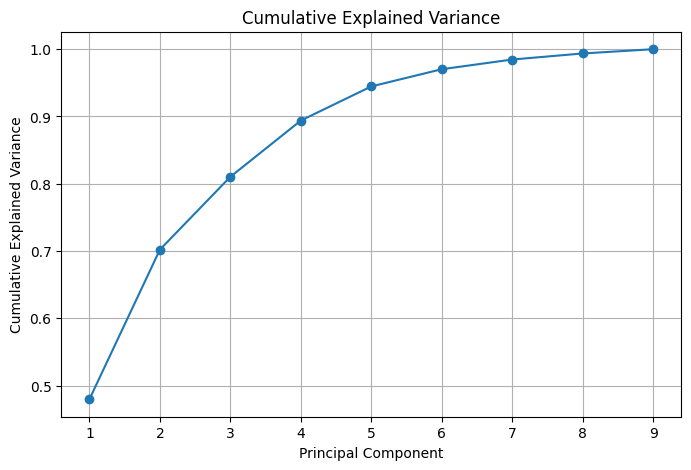

In [569]:
explained_variance = eigenvalues / eigenvalues.sum()

cumulative = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative, marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [570]:
idx = np.argsort(eigenvalues)[::-1]

eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

projection_matrix = eigenvectors[:, :4]
projected_data = np.dot(pca_data, projection_matrix)
print(projected_data.shape)

(18147, 4)


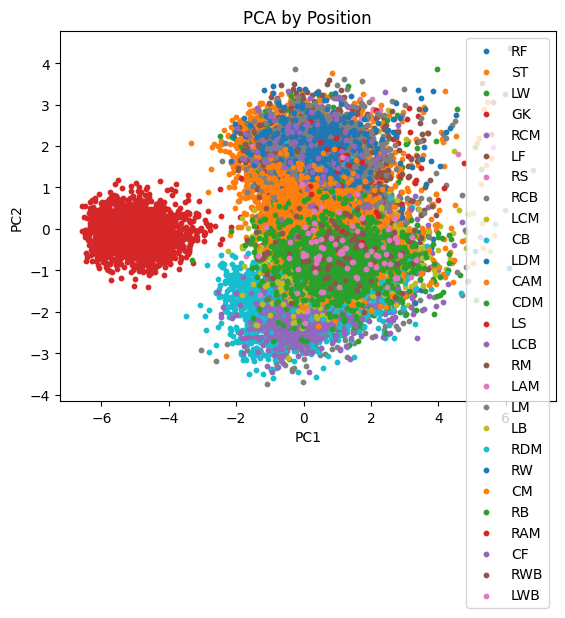

In [571]:
for position in positions.unique():
    mask = positions == position
    plt.scatter(projected_data[mask,0],
                projected_data[mask,1],
                s=10,
                label=position)

plt.legend()
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA by Position")
plt.show()

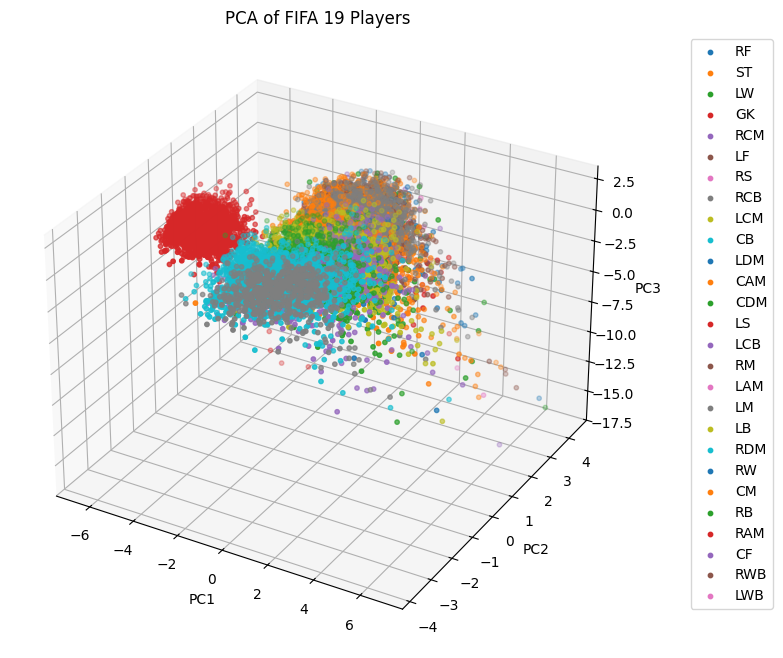

In [572]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

for position in positions.unique():
    mask = positions == position
    ax.scatter(
        projected_data[mask, 0],
        projected_data[mask, 1],
        projected_data[mask, 2],
        s=10,
        label=position
    )

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("PCA of FIFA 19 Players")

ax.legend(bbox_to_anchor=(1.25, 1))
plt.show()

In [573]:
def calculate_mean(column):
    return sum(column) / len(column)

def calculate_std(column):
    m = calculate_mean(column)

    variance = sum((x-m)**2 for x in column) / (len(column)-1)

    return variance**0.5

def z_score(x):
    m = calculate_mean(x)
    std_dev = calculate_std(x)
    z=[]
    for i in range(len(x)):
        z.append((x[i] - m) / std_dev)
    return z

In [574]:
def transpose(matrix):
  transposed = []
  for i in range(len(matrix[0])):
    row = []
    for j in range(len(matrix)):
      row.append(matrix[j][i])
    transposed.append(row)
  return transposed

def matrix_multiply(A, B):
    result = [[0 for _ in range(len(B[0]))] 
              for _ in range(len(A))]

    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                result[i][j] += A[i][k] * B[k][j]

    return result

def covariance(x):

  x_trans = transpose(x)
  covar = matrix_multiply(x_trans, x)

  for i in range(len(covar)):
    for j in range(len(covar[i])):
      covar[i][j] /= (len(x)-1)

  return covar

In [578]:
def pca_pure(X,n):
  x=transpose(X)
  for i in range(len(x)):
    x[i]=z_score(x[i])
  x=transpose(x)
  covariance_matrix = covariance(x)
  eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
  sorted_indices = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[sorted_indices]
  eigenvectors = eigenvectors[:, sorted_indices]
  projection_matrix = eigenvectors[:, :n].tolist()
  projection_data=matrix_multiply(x,projection_matrix)
  return projection_data


def pca_np(X,n):
  z=zscore(X)
  covariance_matrix = np.cov(z.T)
  eigenvalues, eigenvectors = np.linalg.eig(covariance_matrix)
  sorted_indices = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[sorted_indices]
  eigenvectors = eigenvectors[:, sorted_indices]
  projection_matrix = eigenvectors[:, :n]
  projection_data= np.dot(z,projection_matrix)
  return projection_data



pca2=pca_cleaned.copy()
pca2=pca_np(pca2,4)
print(pca2)

[[  6.12177368   4.36077331 -15.60837778   9.26506446]
 [  5.44077273   3.05212733 -11.29132396   4.88313714]
 [  6.43065461   4.33529449 -16.19147259  10.66441994]
 ...
 [ -2.36716682   2.39686282   1.09028219   1.14705098]
 [ -2.14741562   1.6470089    0.40193894   0.45152958]
 [ -1.70215648  -0.20390105   0.27373385   0.29733753]]


In [579]:
pca1=pca_cleaned.copy().values.tolist()
pca1=pca_pure(pca1,4)
print(pca1[0])

[6.121605002658959, 4.360653157047013, -15.607947718440123, 9.26480917383016]
